MLMarker analysis of NCIH1650 after cultivation

In [12]:
#%pip install mlmarker
#%pip install --upgrade openpyxl --force-reinstall

In [13]:
import pandas as pd
from mlmarker import MLMarker

import tqdm
from sklearn.preprocessing import MinMaxScaler

In [14]:
cmb = "CMB-2216"
baseline = "P0"
passage = "P12"

In [15]:
# Load your data
df = pd.read_csv(f"C:/Users/Jeroe/OneDrive - UGent/Thesis/Thesis/Code/ThesisVScode/Data/{cmb}/Protein_Intensities_Wide.csv")

# Set the first column as the index andtranspose the dataframe
df_transposed = df.set_index('Unnamed: 0').T

# Remove the index name for a cleaner look
df_transposed.index.name = 'Sample'
df_transposed.columns.name = None

# Select first, middle ,and last passages
# Calculate the middle start point
mid_grp = (len(df_transposed) // 3) // 2
mid_start = mid_grp * 3

# Define the specific row indices
selected_indices = [
    0, 1, 2,                      # First triplet
    mid_start, mid_start+1, mid_start+2, # Middle triplet
    -3, -2, -1                    # Last triplet
]

# Select
df_final = df_transposed.iloc[selected_indices]
df_final_averaged = df_final.groupby(df_final.index.str.split('_').str[0].astype(int)).mean()

print(df_final_averaged)

        A0A8I5KQE6    A0AV96    A0AVT1    A0FGR8    A0MZ66    A1A4S6  \
Sample                                                                 
1         1.271960 -1.726870 -0.447123 -0.225986 -1.299683 -3.537906   
7         1.259347 -1.693929 -0.303127 -0.081801 -1.316983 -3.069902   
13        0.602145 -1.915790 -1.066862 -0.423481 -1.245548       NaN   

          A1L0T0    A1X283    A2RRP1    A2RTX5  ...    Q9Y6M7    Q9Y6M9  \
Sample                                          ...                       
1      -0.684399  0.169577 -4.481884  1.574382  ... -2.205098 -1.551896   
7      -0.200348  0.451487 -4.237281  1.998587  ... -1.280968 -1.762900   
13     -0.756168 -0.123321 -4.880203  0.329634  ... -2.339253 -1.778621   

          Q9Y6N5    Q9Y6Q5    Q9Y6W3    Q9Y6W5    Q9Y6X4    Q9Y6X9    Q9Y6Y0  \
Sample                                                                         
1       0.317625 -0.392473 -2.522124  0.303014 -2.820965 -1.634117       NaN   
7      -0.090519 -0.274

In [16]:
# Initialize the scaler
scaler = MinMaxScaler()

# Fit and transform the data
# We wrap it back into a DataFrame to keep the row and column labels
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_final_averaged), 
    columns=df_final_averaged.columns, 
    index=df_final_averaged.index
)

Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclud

SHAP force plots: 1


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Visualizing force plot for tissue: Lung


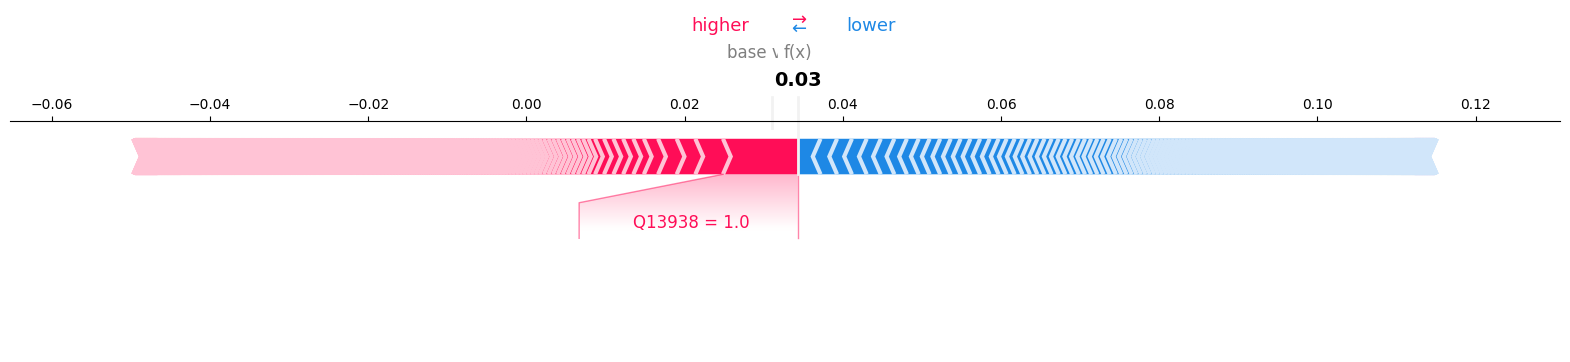

None

Successfully processed passage: 0


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


SHAP force plots: 7


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Visualizing force plot for tissue: Lung


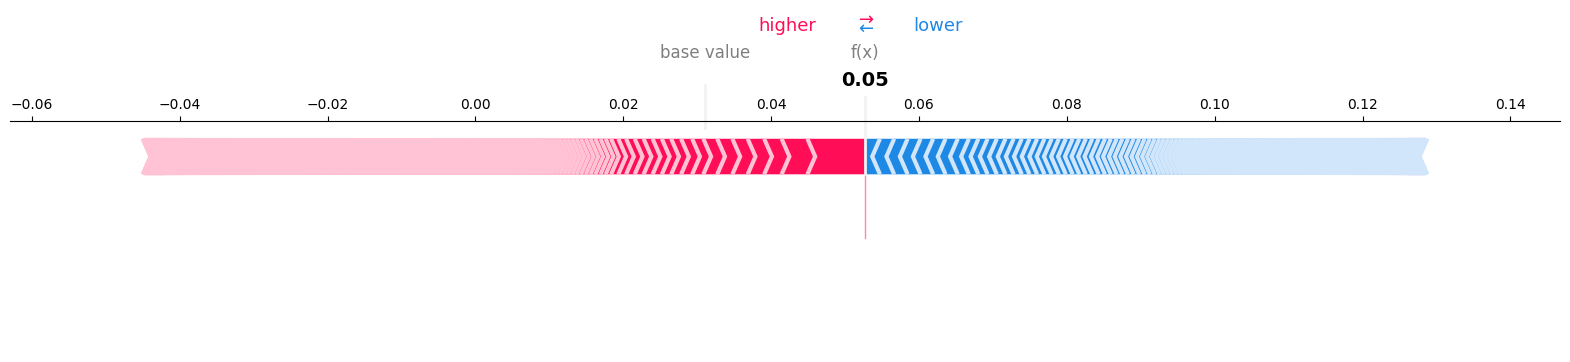

None

Successfully processed passage: 6


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


SHAP force plots: 13


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Visualizing force plot for tissue: Lung


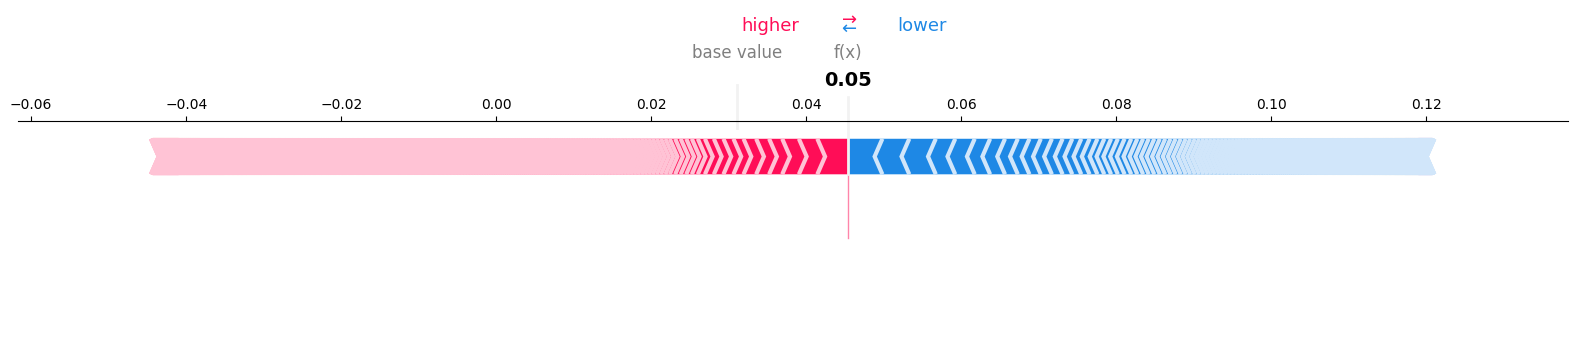

None

Successfully processed passage: 12


In [17]:
model = MLMarker(binary=False, penalty_factor=1)
results = {}
shap_results = {}

for sample_name, protein_data in df_scaled.iterrows():
    # Convert the single row back into a DataFrame format that load_sample expects
    # We transpose it so it looks like a single-column or single-row sample file
    sample_df = pd.DataFrame(protein_data).T 
    
    try:
        # Load the specific sample
        model.load_sample(sample_df)
        
        # Get predictions for this specific sample
        predictions = model.predict_top_tissues_shap(n_preds=10)
        print(f"SHAP force plots: {sample_name}")
        model.shap_force_plot(tissue_name=("Lung"))

        # Get processed SHAP values with optional penalty
        shap_df = model.explainability.get_shap_values(n_preds=10)
        shap_results[sample_name] = shap_df
        
        # Store results using the sample name (e.g., '1_1') as the key
        results[sample_name] = predictions
        print(f"Successfully processed passage: {sample_name - 1}")
        
    except Exception as e:
        print(f"Error processing passage {sample_name - 1}: {e}")

In [18]:
# Initialize a list to store the final per-sample summaries
summary_list = []

# If your keys are now just the sample IDs (e.g., '1', '7', '13')
# rather than '1_1', '1_2', we iterate through them directly.
for sample_id, df in shap_results.items():
    
    # 1. Extract only the 'Lung' row from the SHAP dataframe
    if 'Lung' not in df.index:
        continue
        
    lung_values = df.loc['Lung'].sort_values()

    # 2. Select 10 Lowest (Negative SHAP) and 10 Highest (Positive SHAP)
    lowest_10 = lung_values.head(10)
    highest_10 = lung_values.tail(10)
    
    # 3. Combine them into a single summary dataframe for this sample
    # Note: We name the column 'SHAP_Value' instead of 'Avg_SHAP_Value' since there's no averaging
    sample_summary = pd.concat([lowest_10, highest_10]).to_frame(name='SHAP_Value')
    sample_summary['Sample_ID'] = sample_id
    sample_summary['Protein'] = sample_summary.index
    
    summary_list.append(sample_summary)

# Final Result: One big dataframe containing top/bottom 10 for all samples
if summary_list:
    final_summary_df = pd.concat(summary_list).reset_index(drop=True)
    final_summary_df['Sample_ID'] = pd.to_numeric(final_summary_df['Sample_ID'])
    final_summary_df = final_summary_df.sort_values('Sample_ID')
    
    print(final_summary_df)
else:
    print("No data found.")

    SHAP_Value  Sample_ID Protein
0     -0.00371          1  P17661
19     0.00945          1  Q13938
18     0.00349          1  P48163
17     0.00285          1  A6NMZ7
16     0.00275          1  P15924
15     0.00236          1  Q9HBH5
13     0.00180          1  Q13753
12     0.00140          1  P23141
11     0.00133          1  Q86YZ3
10     0.00132          1  P68871
14     0.00193          1  P98160
8     -0.00159          1  P46779
7     -0.00171          1  Q96SB8
6     -0.00178          1  P02538
5     -0.00187          1  P02585
4     -0.00188          1  P35573
3     -0.00209          1  P09543
2     -0.00212          1  Q14315
1     -0.00288          1  P07476
9     -0.00138          1  Q9Y678
32     0.00188          7  P56199
33     0.00205          7  O95833
34     0.00207          7  P17900
35     0.00223          7  Q13753
39     0.00777          7  Q13938
37     0.00252          7  A6NMZ7
38     0.00349          7  P48163
31     0.00150          7  Q99832
36     0.00236

In [19]:
# Load your DE proteins from the .txt file
with open(f"C:/Users/Jeroe/OneDrive - UGent/Thesis/Thesis/Code/ThesisRStudio/results/{cmb}/{passage}_vs_{baseline}/dea_lists/Pair_DOWN_{passage}_vs_{baseline}.txt", "r") as f:
    de_proteins_pair_down = [line.strip() for line in f.readlines()]

# Check for matches
final_summary_df_Pair_DOWN = final_summary_df.copy()
final_summary_df_Pair_DOWN['Is_DE'] = final_summary_df['Protein'].isin(de_proteins_pair_down)

# 3. Filter to see only the matches
matches_pair_down = final_summary_df_Pair_DOWN[final_summary_df_Pair_DOWN['Is_DE'] == True]

print(f"Found {len(matches_pair_down)} matches between SHAP top/bottom proteins and DE proteins.")
print(matches_pair_down)

Found 7 matches between SHAP top/bottom proteins and DE proteins.
    SHAP_Value  Sample_ID Protein  Is_DE
19     0.00945          1  Q13938   True
11     0.00133          1  Q86YZ3   True
3     -0.00209          1  P09543   True
33     0.00205          7  O95833   True
39     0.00777          7  Q13938   True
22    -0.00204          7  P13647   True
24    -0.00182          7  P09543   True


In [20]:
# Load your DE proteins from the .txt file
with open(f"C:/Users/Jeroe/OneDrive - UGent/Thesis/Thesis/Code/ThesisRStudio/results/{cmb}/{passage}_vs_{baseline}/dea_lists/Pair_UP_{passage}_vs_{baseline}.txt", "r") as f:
    de_proteins_pair_up = [line.strip() for line in f.readlines()]

# Check for matches
final_summary_df_Pair_UP = final_summary_df.copy()
final_summary_df_Pair_UP['Is_DE'] = final_summary_df['Protein'].isin(de_proteins_pair_up)

# 3. Filter to see only the matches
matches_pair_up = final_summary_df_Pair_UP[final_summary_df_Pair_UP['Is_DE'] == True]

print(f"Found {len(matches_pair_up)} matches between SHAP top/bottom proteins and DE proteins.")
print(matches_pair_up)

Found 1 matches between SHAP top/bottom proteins and DE proteins.
    SHAP_Value  Sample_ID Protein  Is_DE
45    -0.00165         13  P07996   True


In [21]:
# Load your DE proteins from the .txt file
with open(f"C:/Users/Jeroe/OneDrive - UGent/Thesis/Thesis/Code/ThesisRStudio/results/{cmb}/{passage}_vs_{baseline}/dea_lists/Trend_DOWN_{passage}_vs_{baseline}.txt", "r") as f:
    de_proteins_trend_down = [line.strip() for line in f.readlines()]

# Check for matches
final_summary_df_Trend_DOWN = final_summary_df.copy()
final_summary_df_Trend_DOWN['Is_DE'] = final_summary_df['Protein'].isin(de_proteins_trend_down)

# 3. Filter to see only the matches
matches_trend_down = final_summary_df_Trend_DOWN[final_summary_df_Trend_DOWN['Is_DE'] == True]

print(f"Found {len(matches_trend_down)} matches between SHAP top/bottom proteins and DE proteins.")
print(matches_trend_down)

Found 6 matches between SHAP top/bottom proteins and DE proteins.
    SHAP_Value  Sample_ID Protein  Is_DE
19     0.00945          1  Q13938   True
3     -0.00209          1  P09543   True
33     0.00205          7  O95833   True
39     0.00777          7  Q13938   True
28    -0.00128          7  P05187   True
24    -0.00182          7  P09543   True


In [22]:
# Load your DE proteins from the .txt file
with open(f"C:/Users/Jeroe/OneDrive - UGent/Thesis/Thesis/Code/ThesisRStudio/results/{cmb}/{passage}_vs_{baseline}/dea_lists/Trend_UP_{passage}_vs_{baseline}.txt", "r") as f:
    de_proteins_trend_up = [line.strip() for line in f.readlines()]

# Check for matches
final_summary_df_Trend_UP = final_summary_df.copy()
final_summary_df_Trend_UP['Is_DE'] = final_summary_df['Protein'].isin(de_proteins_trend_up)

# 3. Filter to see only the matches
matches_trend_up = final_summary_df_Trend_UP[final_summary_df_Trend_UP['Is_DE'] == True]

print(f"Found {len(matches_trend_up)} matches between SHAP top/bottom proteins and DE proteins.")
print(matches_trend_up)

Found 1 matches between SHAP top/bottom proteins and DE proteins.
    SHAP_Value  Sample_ID Protein  Is_DE
57     0.00169         13  Q6UXH1   True
